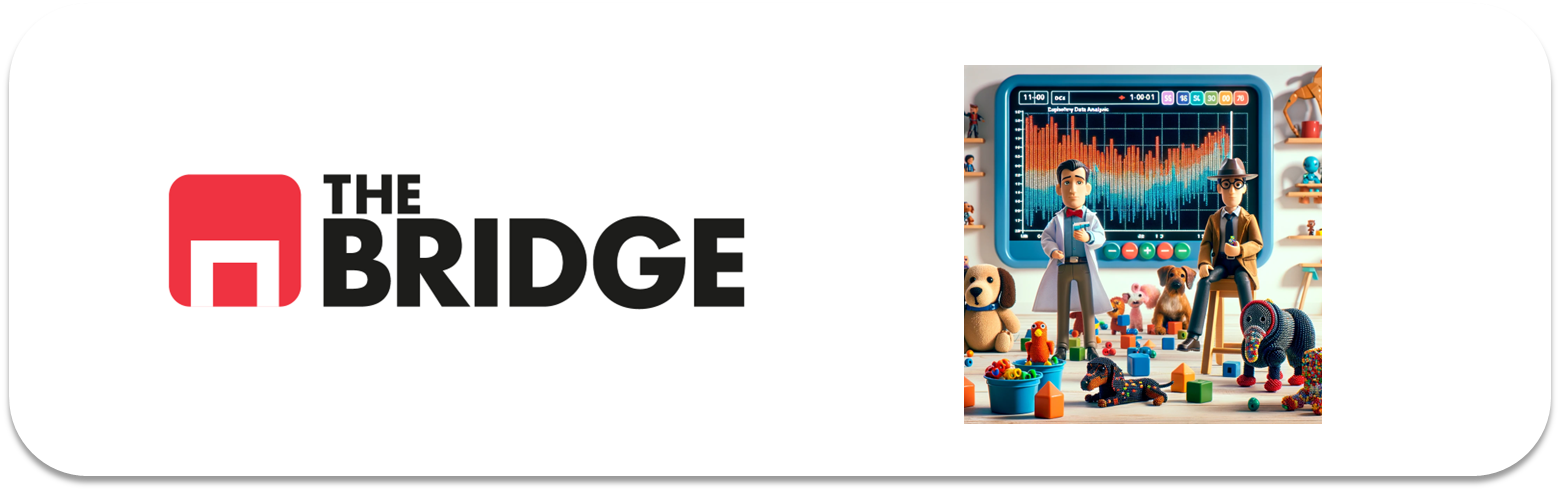

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bootcampviztools import plot_categorical_numerical_relationship, plot_combined_graphs, \
    pinta_distribucion_categoricas, plot_grouped_boxplots, plot_categorical_relationship_fin, plot_grouped_histograms, \
        grafico_dispersion_con_correlacion, bubble_plot


## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [60]:
df_titanic = pd.read_csv("./data/titanic.csv")

### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [61]:
df_titanic.drop(columns=["deck", "survived", "pclass", "embarked"], inplace=True)

In [62]:
df_titanic.sample(5)

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
82,female,NaN,0,0,7.7875,Third,woman,False,Queenstown,yes,True
847,male,35.0,0,0,7.8958,Third,man,True,Cherbourg,no,True
513,female,54.0,1,0,59.4000,First,woman,False,Cherbourg,yes,False
787,male,8.0,4,1,29.1250,Third,child,False,Queenstown,no,False
650,male,NaN,0,0,7.8958,Third,man,True,Southampton,no,True


### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [63]:
df_titanic["family_members"] = df_titanic.parch + df_titanic.sibsp
df_titanic.sample()

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,family_members
214,male,NaN,1,0,7.75,Third,man,True,Queenstown,no,False,1


In [64]:
df_titanic.drop(columns=["parch", "sibsp"], inplace=True)
df_titanic.sample()

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
188,male,40.0,15.5,Third,man,True,Queenstown,no,False,2


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [65]:
# para poder comprobarlos
df_titanic.loc[df_titanic.embark_town.isna()]

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
61,female,38.0,80.0,First,woman,False,NaN,yes,True,0
829,female,62.0,80.0,First,woman,False,NaN,yes,True,0


In [66]:
df_titanic.loc[df_titanic.embark_town.isna(), "embark_town"] = df_titanic.embark_town.mode()[0]


In [67]:
df_titanic.iloc[[61, 829]]

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
61,female,38.0,80.0,First,woman,False,Southampton,yes,True,0
829,female,62.0,80.0,First,woman,False,Southampton,yes,True,0


### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [68]:
df_titanic.loc[df_titanic.age.isna() & df_titanic.who.isin(["child"])]

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members


In [69]:
df_titanic.loc[df_titanic.age.isna() & df_titanic.who.isin(["man", "woman"])]

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
5,male,NaN,8.4583,Third,man,True,Queenstown,no,True,0
17,male,NaN,13.0000,Second,man,True,Southampton,yes,True,0
19,female,NaN,7.2250,Third,woman,False,Cherbourg,yes,True,0
26,male,NaN,7.2250,Third,man,True,Cherbourg,no,True,0
28,female,NaN,7.8792,Third,woman,False,Queenstown,yes,True,0
...,...,...,...,...,...,...,...,...,...,...
859,male,NaN,7.2292,Third,man,True,Cherbourg,no,True,0
863,female,NaN,69.5500,Third,woman,False,Southampton,no,False,10
868,male,NaN,9.5000,Third,man,True,Southampton,no,True,0
878,male,NaN,7.8958,Third,man,True,Southampton,no,True,0


In [70]:
# La edad es un entero
df_titanic.loc[df_titanic.age.isna() & df_titanic.who.isin(["child"]),"age"]= int(df_titanic.loc[df_titanic.who.isin(["child"]), "age"].mean())
df_titanic.loc[df_titanic.age.isna() & df_titanic.who.isin(["man", "woman"]),"age"]= int(df_titanic.loc[df_titanic.who.isin(["man", "woman"]), "age"].mean())

In [73]:
df_titanic.iloc[[5, 17, 28, 888]]

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
5,male,32.0,8.4583,Third,man,True,Queenstown,no,True,0
17,male,32.0,13.0000,Second,man,True,Southampton,yes,True,0
28,female,32.0,7.8792,Third,woman,False,Queenstown,yes,True,0
888,female,32.0,23.4500,Third,woman,False,Southampton,no,False,3


### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

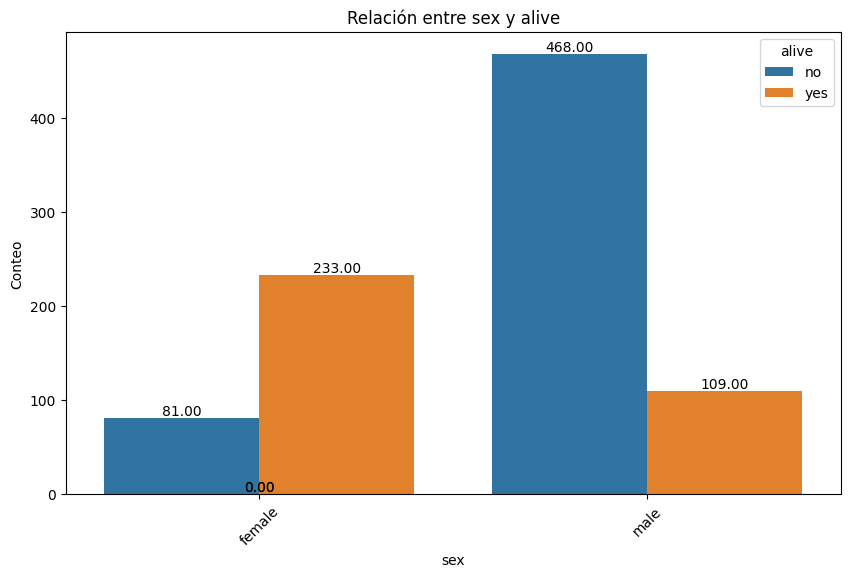

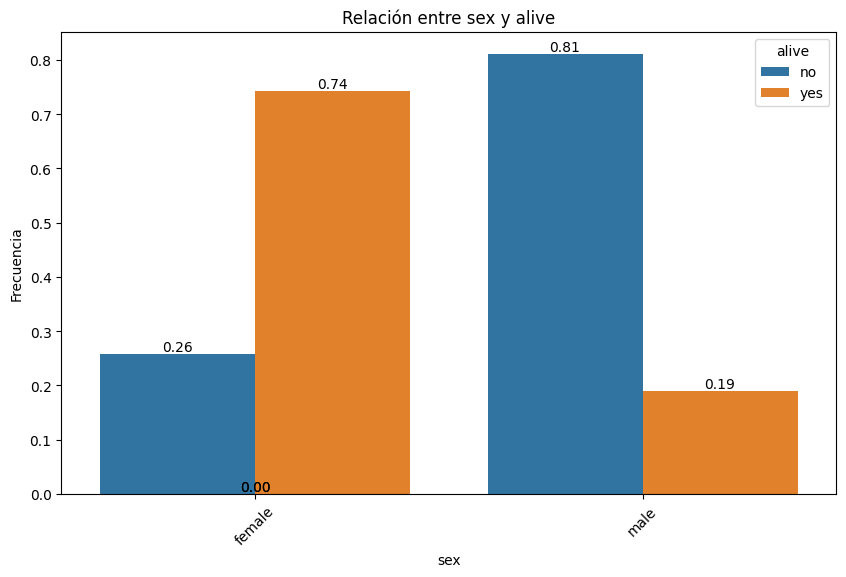

In [97]:
# 1. relacion alive-sex
plot_categorical_relationship_fin(df_titanic, "sex","alive", relative_freq = False, show_values = True)
plot_categorical_relationship_fin(df_titanic, "sex","alive", relative_freq = True, show_values = True)

In [78]:
tabla_contingencia = pd.crosstab(df_titanic['alive'], df_titanic['sex'])

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 260.71702016732104
P-Value: 1.1973570627755645e-58
Grados de Libertad: 1
Tabla de Frecuencias Esperadas:
 [[193.47474747 355.52525253]
 [120.52525253 221.47474747]]


Con un p-valor mucho menor al nivel de significacion de 0,05, tenemos suficiente evidencia estadística para rechazar la hiótesis nula (las variables son independientes) y acpetar la alternativa, concluyendo que las variables de sexo y supervivencia al accidente del titanic están correlacionadas. Particularmente, las mujeres sonrevivieron en mayor proporción que los hombres.

Las relaciones absolutas y relativas son muy similares dado el tamaño de los grupos hombres y mujeres, sobreviviendo más mujeres tanto en cantidad como en proporción.

In [ ]:
# relación niño-adulto
df_titanic["adulto"] = df_titanic.who.isin(["man", "woman"])
df_titanic.sample(5)

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members,adulto
169,male,28.0,56.4958,Third,man,True,Southampton,no,True,0,True
322,female,30.0,12.3500,Second,woman,False,Queenstown,yes,True,0,True
869,male,4.0,11.1333,Third,child,False,Southampton,yes,False,2,False
602,male,32.0,42.4000,First,man,True,Southampton,no,True,0,True
80,male,22.0,9.0000,Third,man,True,Southampton,no,True,0,True


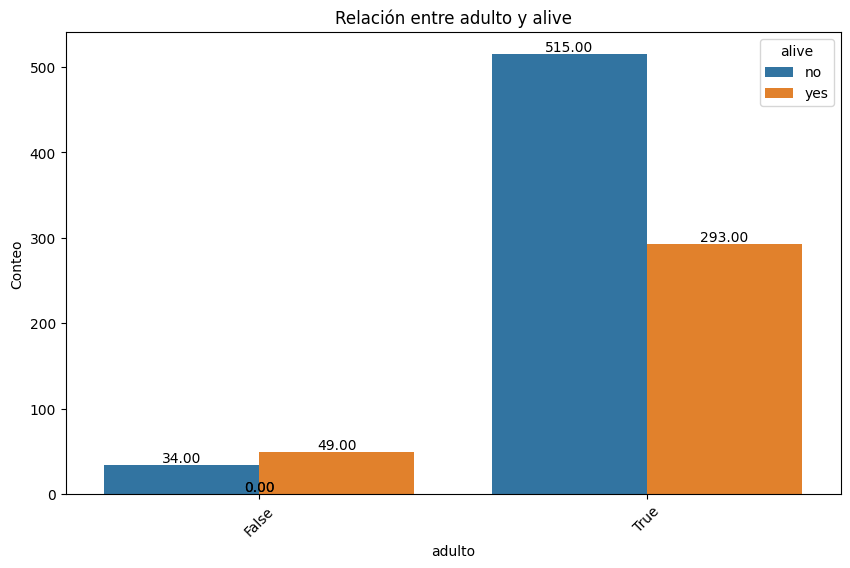

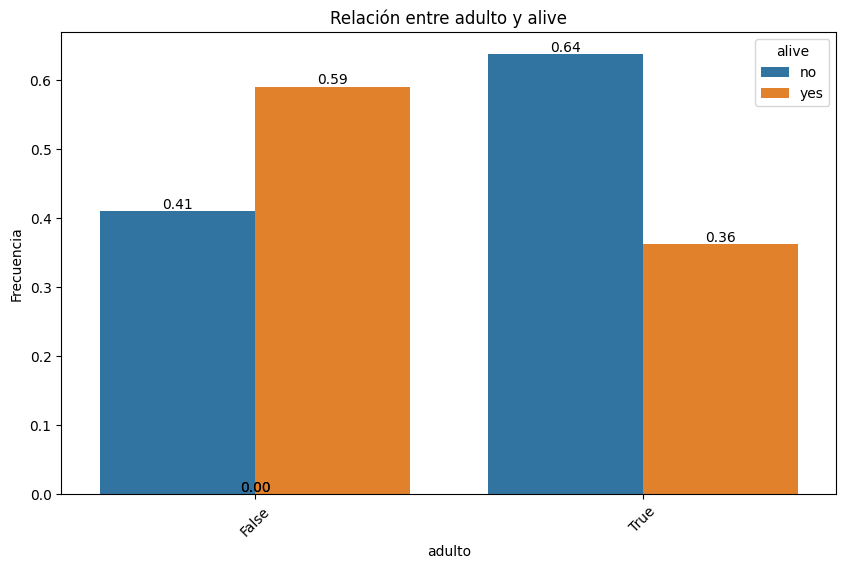

In [ ]:
# adulto -supervivencia
plot_categorical_relationship_fin(df_titanic, "adulto", "alive", relative_freq = False, show_values = True)
plot_categorical_relationship_fin(df_titanic, "adulto", "alive", relative_freq = True, show_values = True)

In [ ]:
tabla_contingencia = pd.crosstab(df_titanic['alive'], df_titanic['adulto'])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)



Valor Chi-Cuadrado: 15.556993340077092
P-Value: 8.005497211300105e-05
Grados de Libertad: 1


Con un p-valor menor que el nivel de significación establecido en 0,05, existe suficiente evidencia estadística para rechazar la hipótesis nula y aceptar que existe una correlaciñón entre la clasificación adulto-niño y su supervivencia en el Titanic.. La relación entre la supervivencia de adultos y niños también es significativa, sobreviviendo una mayoría de niños respecto de una minoría de adultos.

A niveles absolutos, sobrevivieron más adultos que niños, pero proporcionalmente al total de su grupo, los niños tuvieron un mayor ratio de supervivencia.

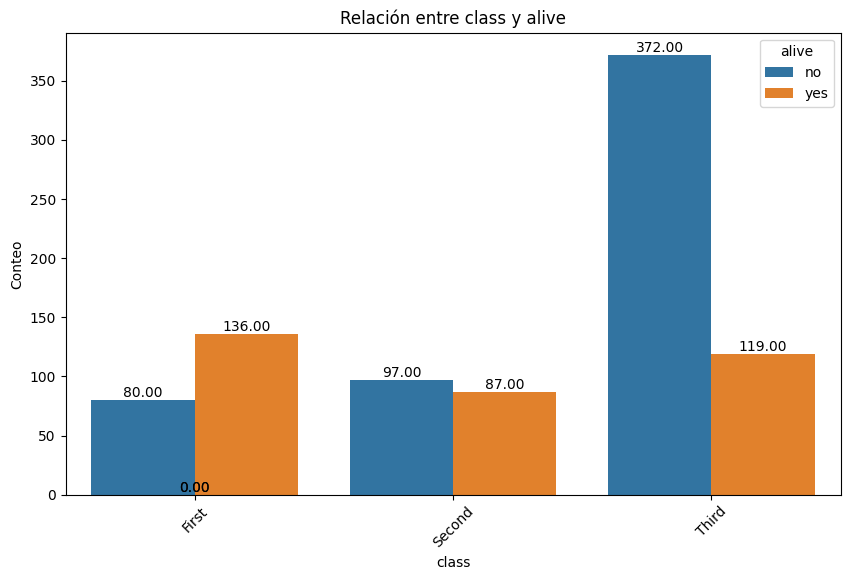

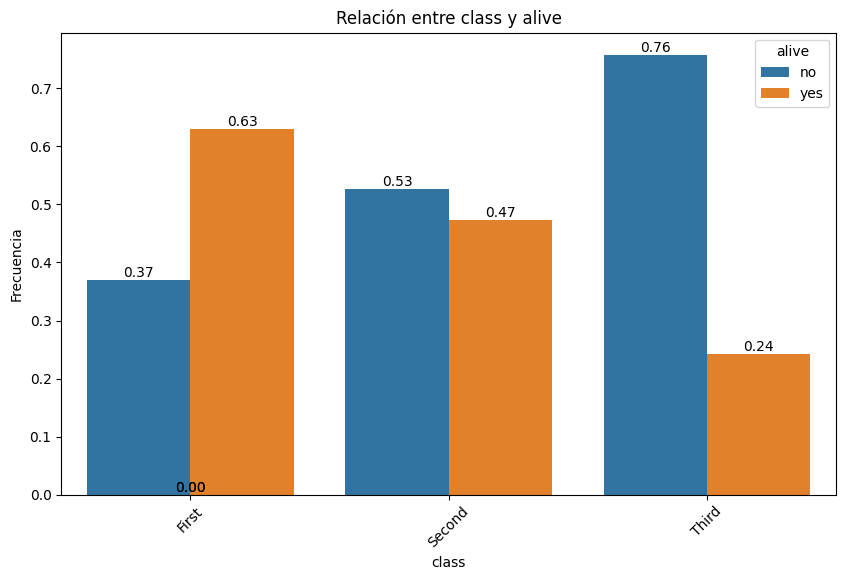

Valor Chi-Cuadrado: 102.88898875696056
P-Value: 4.549251711298793e-23
Grados de Libertad: 2


In [ ]:
# 2. clases - supervivencia
plot_categorical_relationship_fin(df_titanic, "class", "alive", relative_freq = False, show_values = True)
plot_categorical_relationship_fin(df_titanic, "class", "alive", relative_freq = True, show_values = True)

tabla_contingencia = pd.crosstab(df_titanic['alive'], df_titanic['class'])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)

De nuevo, la relación es significativa, indicando una dependencia entre la supervivencia del pasajero y la clase de su ticket, sobreviviendo un 63% de los pasajeros en primera clase, un 47% de segunda y un 24% de tercera clase. Sin embargo, en términos absolutos sobrevivieron más pasajeros de tercera clase que de segunda y casi los mismos en primera y en tercera.

Dada la gran magnitud de pasajeros en tercera clase que había en el titanic, su proporción de supervivientes es muy baja, pero es la segunda clase en la que más supervivientes hay (después de la primera, como ya hemos mencionado).

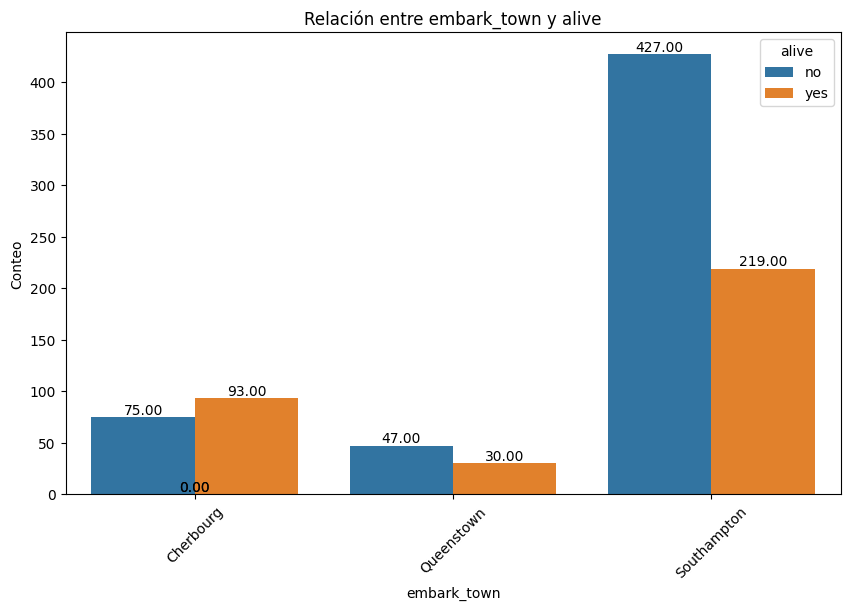

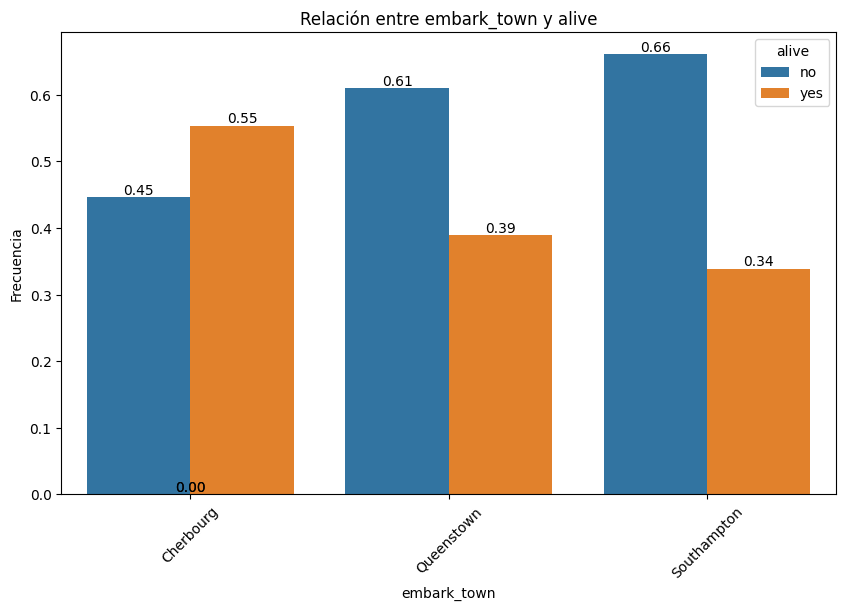

Valor Chi-Cuadrado: 25.964452881874784
P-Value: 2.3008626481449577e-06
Grados de Libertad: 2


In [ ]:
# 3. Ciudad de embarque - supervivencia
plot_categorical_relationship_fin(df_titanic, "embark_town", "alive", relative_freq = False, show_values = True)
plot_categorical_relationship_fin(df_titanic, "embark_town", "alive", relative_freq = True, show_values = True)

tabla_contingencia = pd.crosstab(df_titanic['alive'], df_titanic['embark_town'])

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)

Analizando los supervivientes respecto de la ciudad de embarque, Southampton cuenta tanto con el mayor número de supervivientes como con el mayor número de fallecidos en números brutos. Sin embargo, Cherbourg es la ciudad con mayor ratio de supervivientes, seguida de Queenstown y con Southampton con el menor porcentaje de supervivientes. Esta relación es significativa, con un p-valor mucho menor al nivel de significación de 0,05, indicando que podemos aceptar la hipótesis alternativa de la relación entre las variables de supervivencia y ciudad de embarque.

(2,)


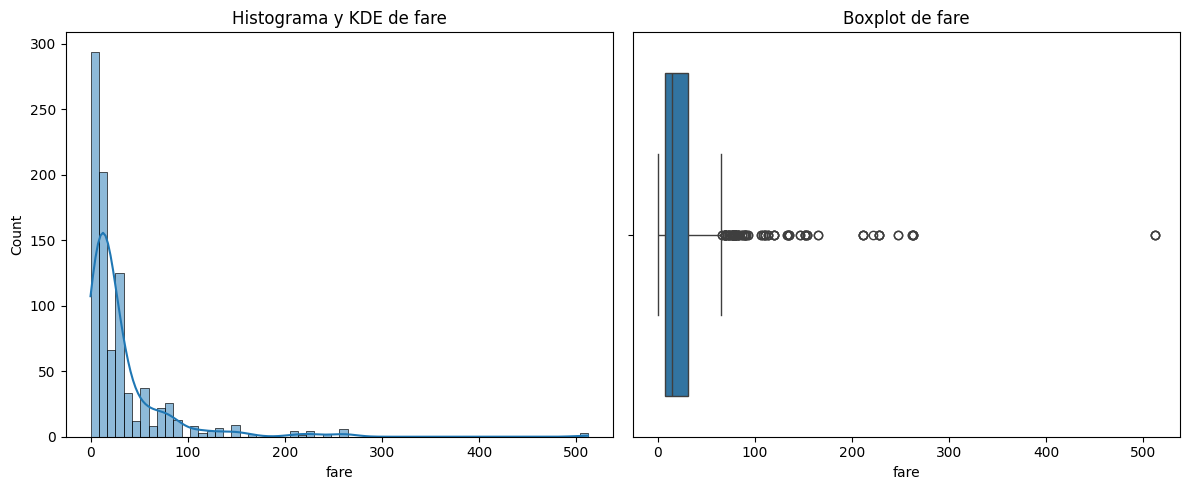

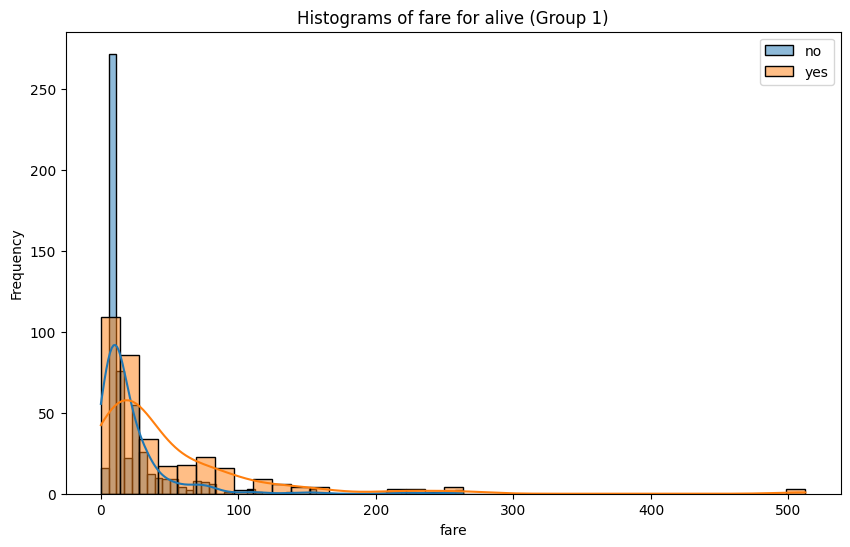

In [ ]:
# 4. precio - supervivencia
plot_combined_graphs(df_titanic,["fare"])
plot_grouped_histograms(df_titanic, cat_col="alive",num_col="fare", group_size= 2)

In [ ]:
# test de Mann-Whitney
from scipy.stats import mannwhitneyu
grupo_a = df_titanic.loc[df_titanic.alive == "yes"]["fare"]
grupo_b = df_titanic.loc[df_titanic.alive == "no"]["fare"]
u_stat, p_valor = mannwhitneyu(grupo_a, grupo_b)

print("Estadístico U:", u_stat)
print("Valor p:", p_valor)

Estadístico U: 129951.5
Valor p: 4.553477179250237e-22


El test de Mann-Whitney entre las variables _fare_ y _alive_, con un p-valor mucho menor al nivel de significación de 0,05, indica que existe suficiente evidencia estadística para afirmar que las medianas de los datos en la variable _fare_ contrastada con la supervivencia del pasajero es significativa.

En los gráficos se puede observar que la distribución de los fallecidos respecto del precio de su ticket está mucho más concentrada hacia los precios bajos que la de los supervivientes. Esto es de esperar dadas las conclusiones obtenidas al comparar la supervivencia de los pasajeros con su clase.

5. Los pasajeros que figuran sin precio de billete probablemente se traten del personal del barco. Idelamente, podríamos contar con una variable que indique si el pasajero formaba parte del personal, para poder separar este grupo de los pasajeros comerciales. Esto también puede ayudar a explicar el elevado número de fallecidos en los rangos bajos de precio, dado que el personal era encargado de evacuar y mantener los sistemas de emergancia, resultando en un ratio de supervivencia muy probablemente más bajo; pero esta conclusión se debe corroborar con un análisis riguroso.

In [105]:
# El pasajero con el billete más caro
df_titanic.loc[df_titanic.fare.argmax()]

sex                  female
age                    35.0
fare               512.3292
class                 First
who                   woman
adult_male            False
embark_town       Cherbourg
alive                   yes
alone                  True
family_members            0
adulto                 True
Name: 258, dtype: object

El pasajero con el billete más caro fue una mujer que viajaba sola en primera clase y sobrevivió el accidente.

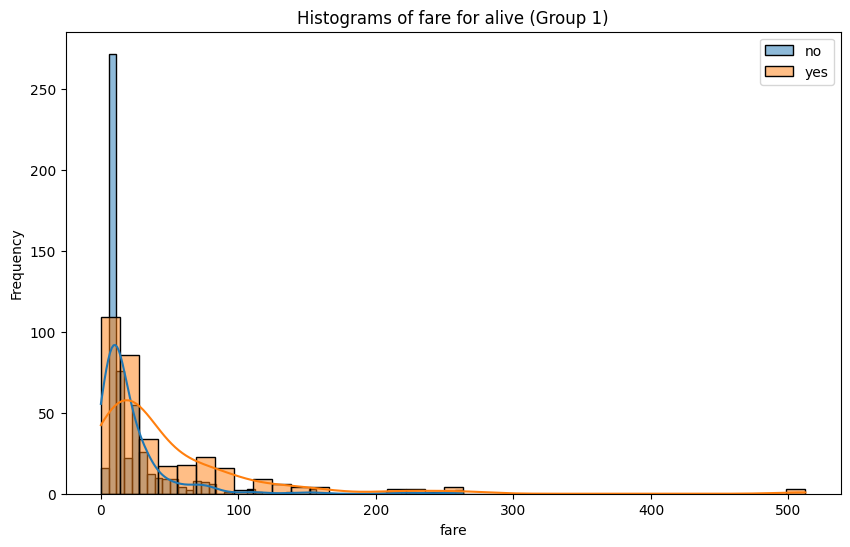

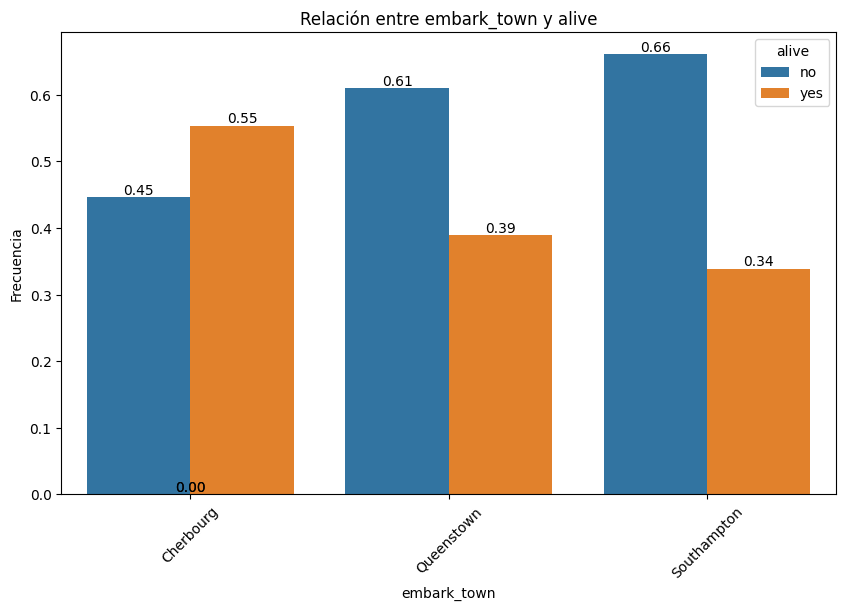

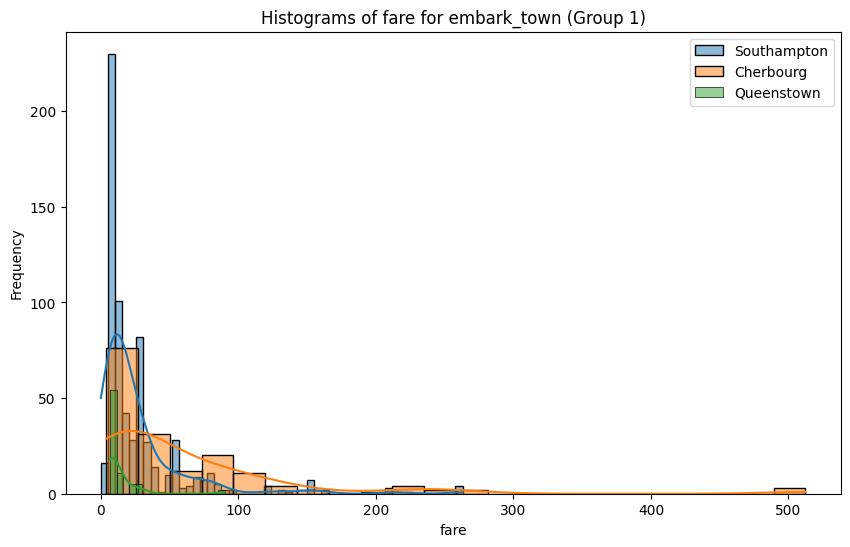

In [118]:
# 6. relación fare-embark_town-alive
plot_grouped_histograms(df_titanic, cat_col="alive",num_col="fare", group_size= 2)
plot_categorical_relationship_fin(df_titanic,"embark_town","alive", relative_freq= True, show_values= True)
plot_grouped_histograms(df_titanic, cat_col="embark_town",num_col="fare", group_size= 3)

Las Distribuciones de fallecimientos y pasajeros embarcados en Southampton muestran una distribución de precios de ticket muy similares. Esto probablemente se de por los anteriormente mencionados miembros del personal, pues Southampton fue la ciudad donde inició el trayecto el Titanic; de modo que la correlación entre las variables está principalmente dada por el personal, con precio de ticket 0$, que, por los procedimientos de evacuación y su rol en el barco, no sobrevivieron.

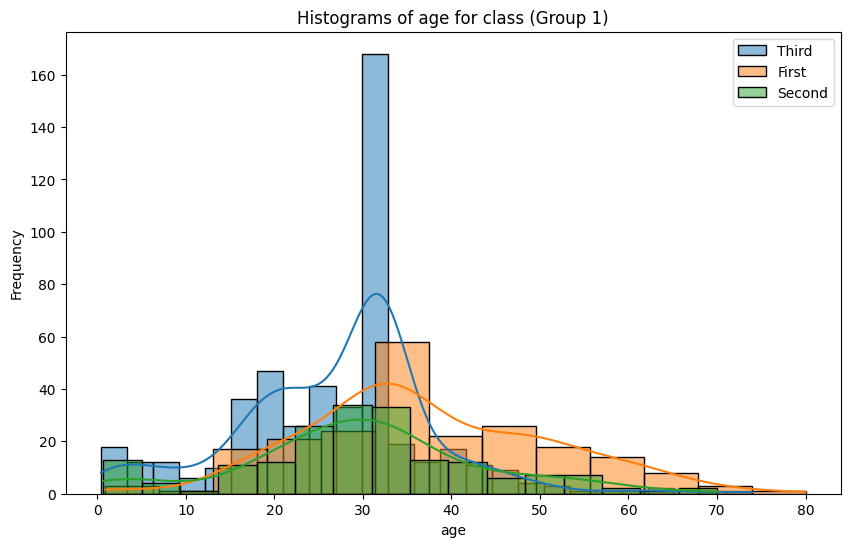

In [ ]:
# 7. relación clase - edad - supervivencia
plot_grouped_histograms(df_titanic, cat_col="class", num_col="age", group_size= 3)

In [139]:
cofactores = ["class","age", "alive"] 
var_dep = "alive"
cof_1 = [var for var in cofactores if var != var_dep][0]
cof_2 = [var for var in cofactores if var != var_dep][1]
diccionario_multivariante = {}
for valor in df_titanic[var_dep].unique():
    diccionario_multivariante[valor] = df_titanic.loc[df_titanic[var_dep] == valor,[cof_2, cof_1]]

Respuesta no:


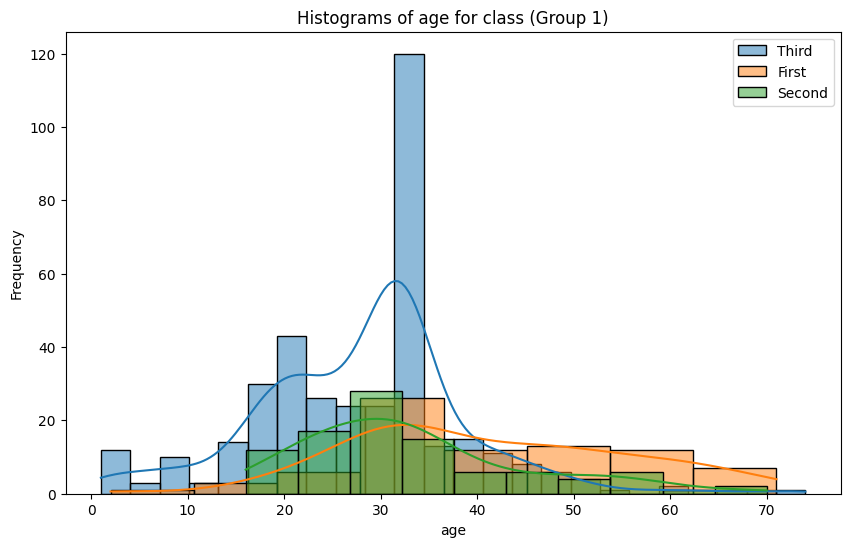

Respuesta yes:


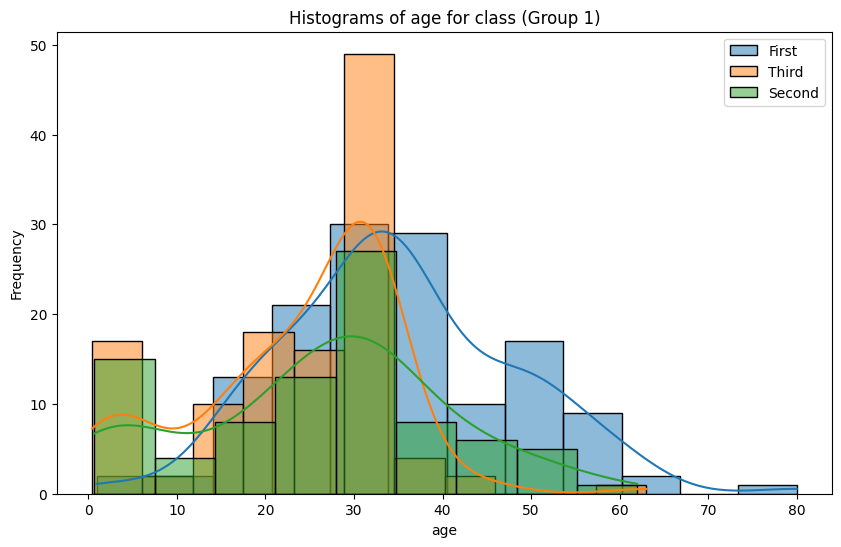

In [ ]:
for valor,df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    plot_grouped_histograms(df_datos, cat_col=cof_1, num_col=cof_2, group_size= 3)  # hacer un histograma categórico para age no tiene sentido, age es suficientemente numérica

Sobrevivieron más los pasajeros en tercera clase entre los 35 y los 35.

Si hicieramos histogramas categóricos para age podríamos determinar la edad exacta con mayor supervivencia, pero no tiene sentido porque no hay suficientes datos por cada edad específica para poder evaluar su relación con la supervivencia.

Respuesta yes:


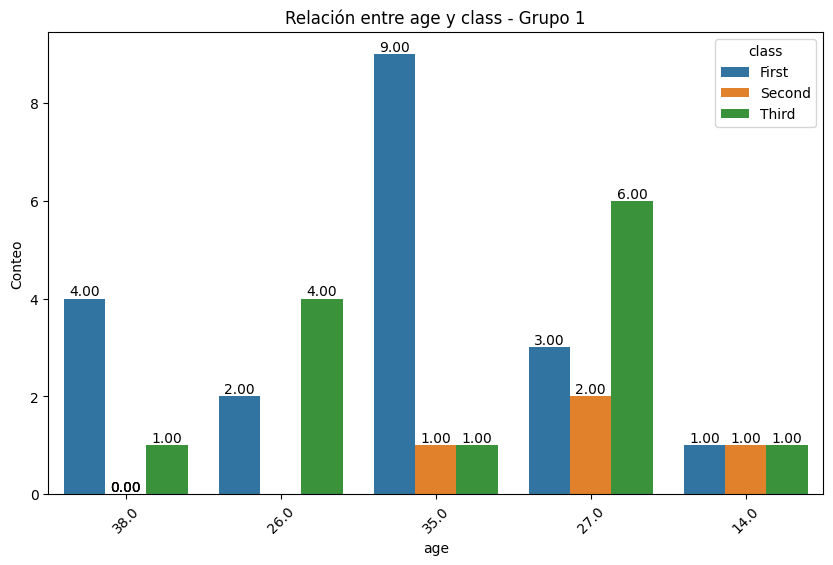

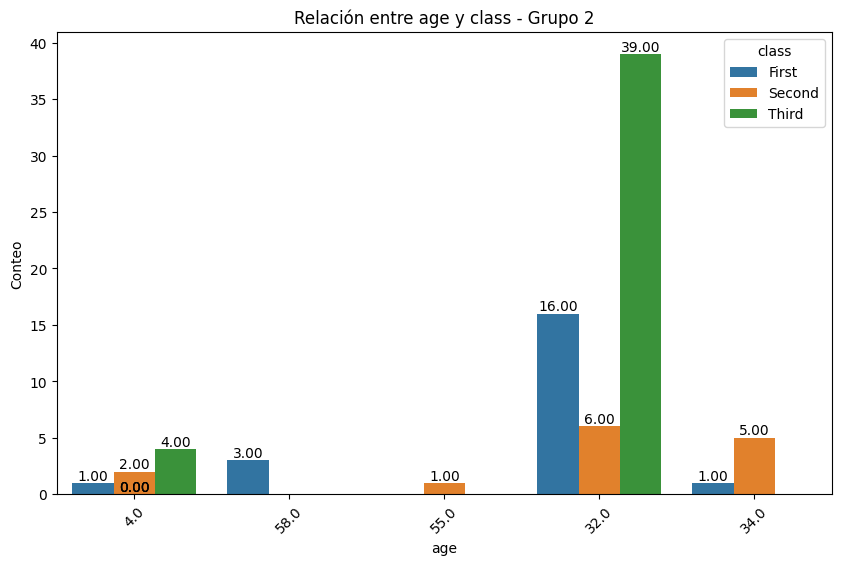

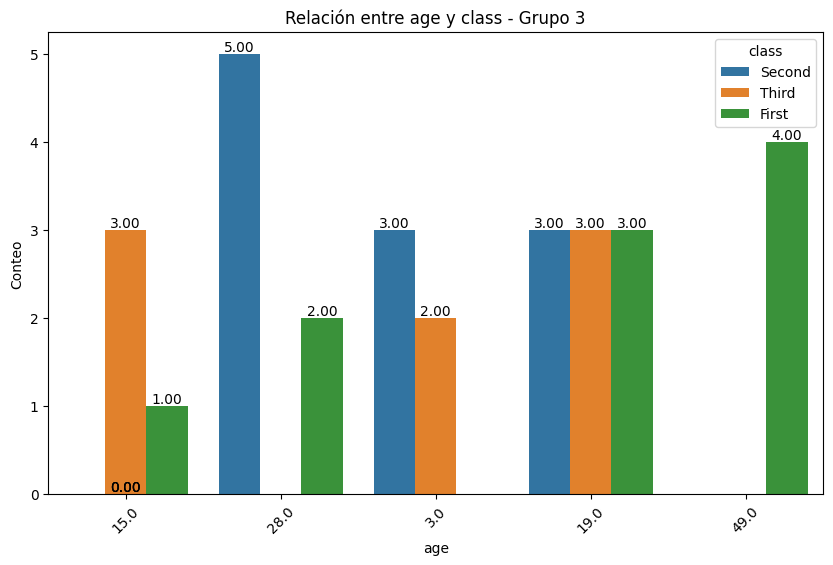

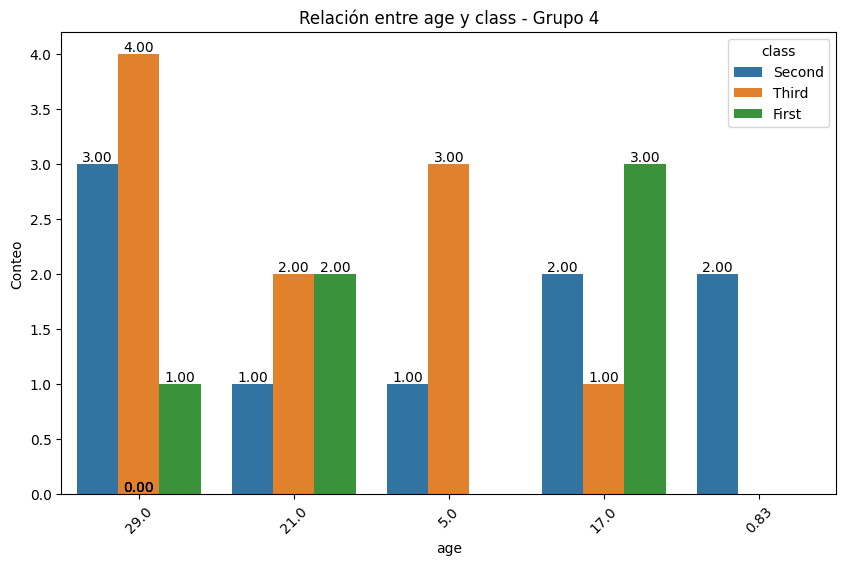

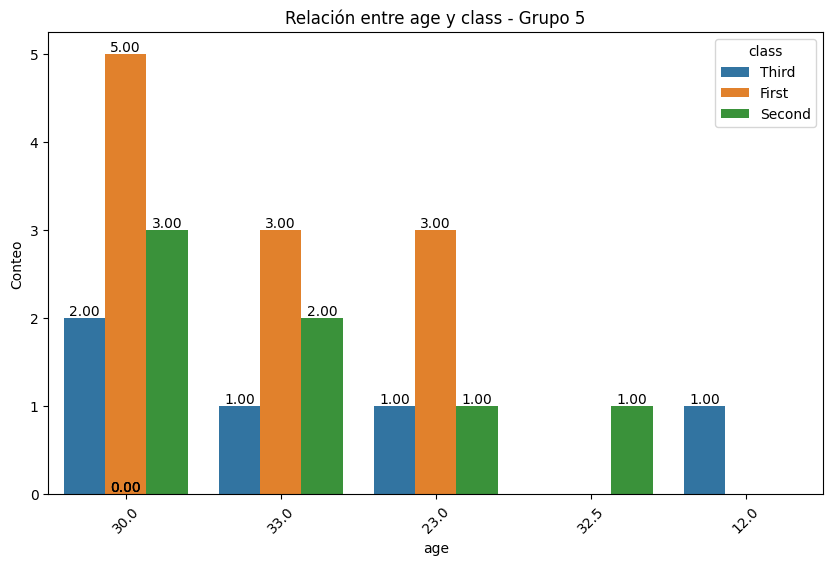

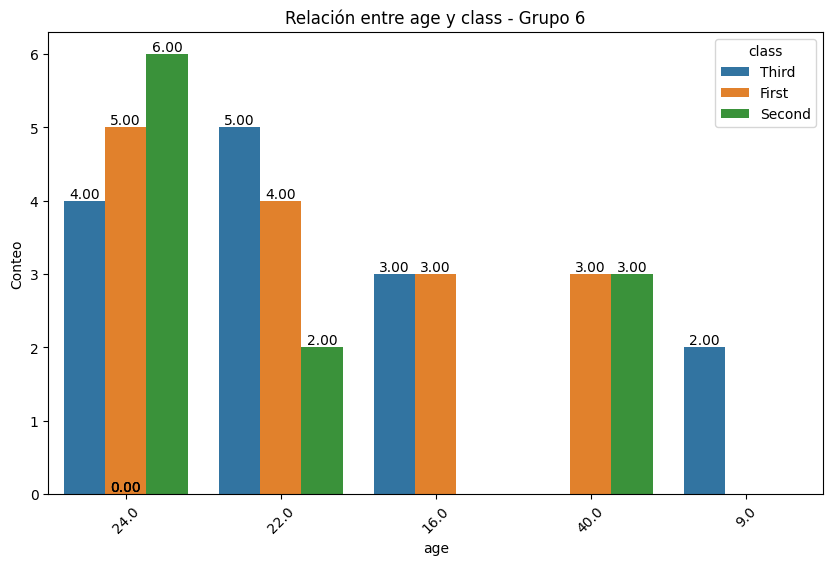

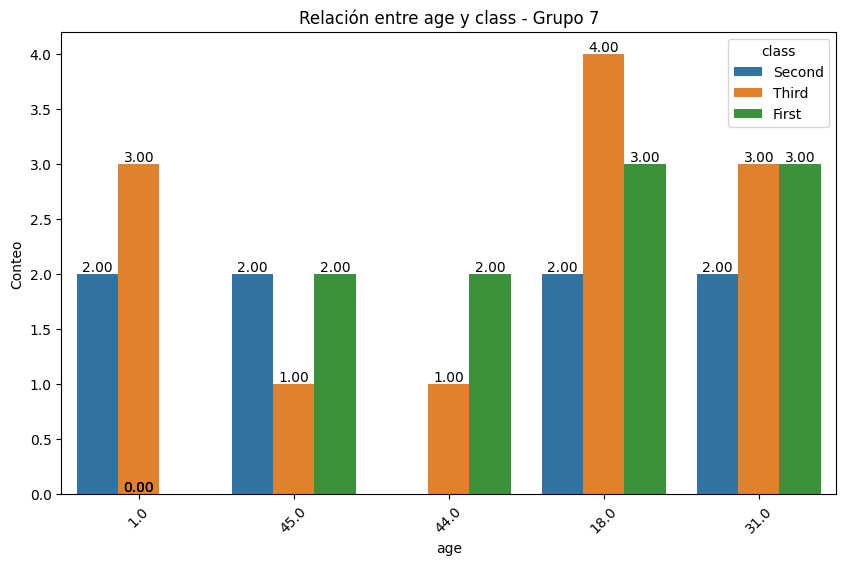

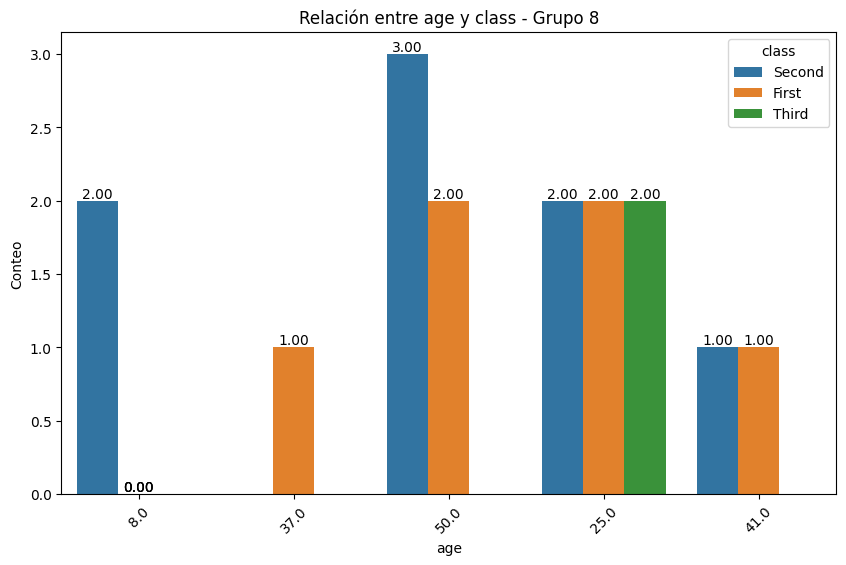

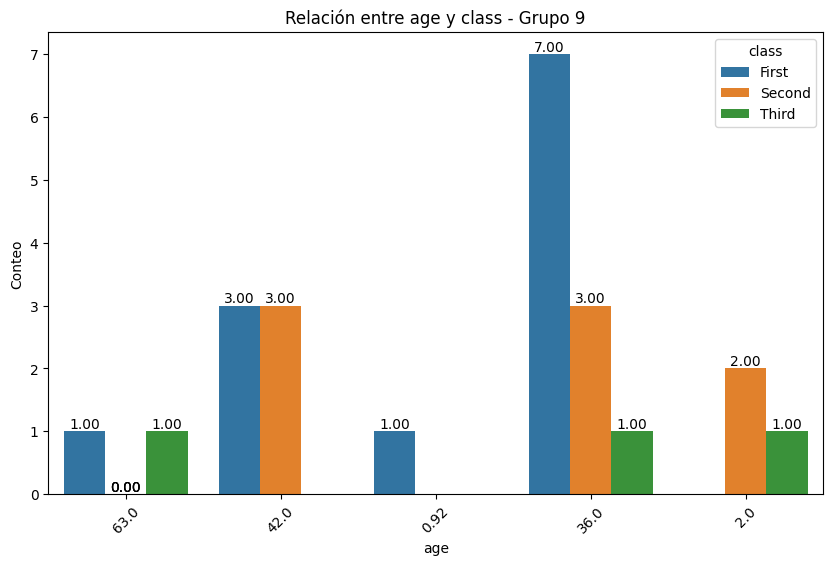

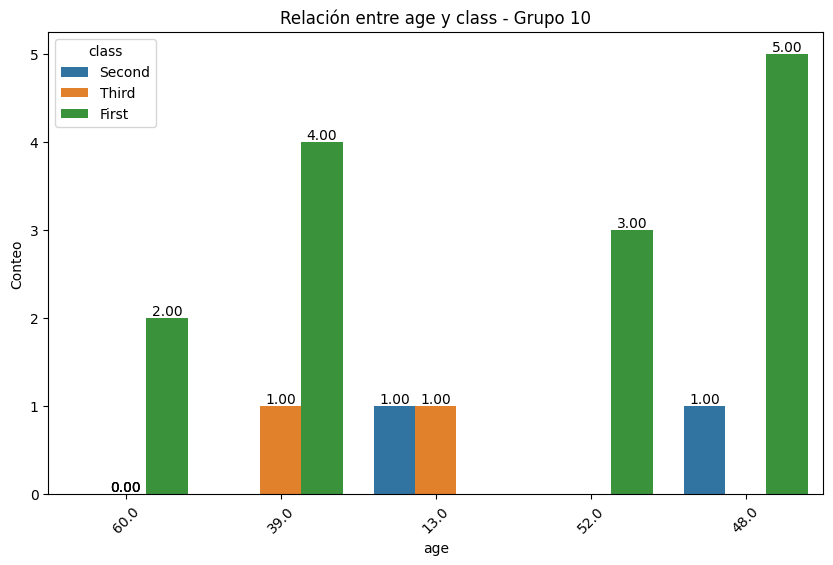

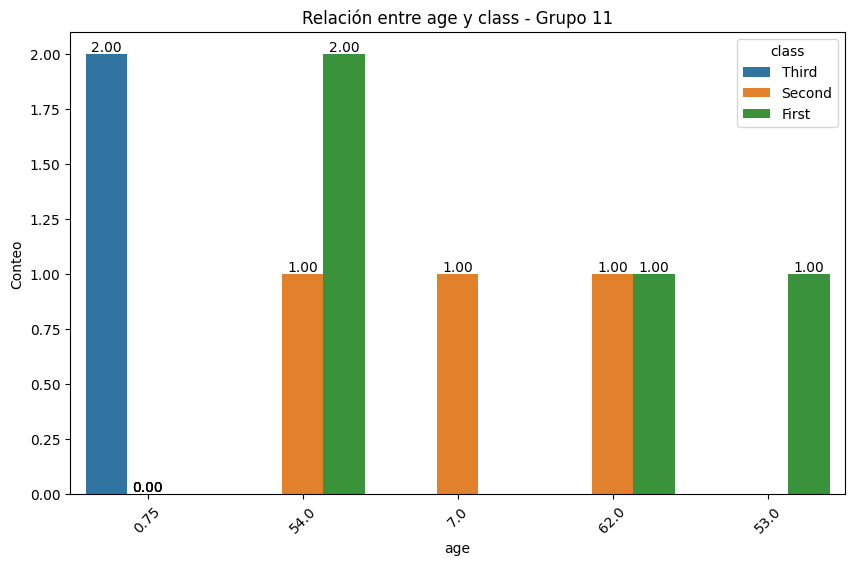

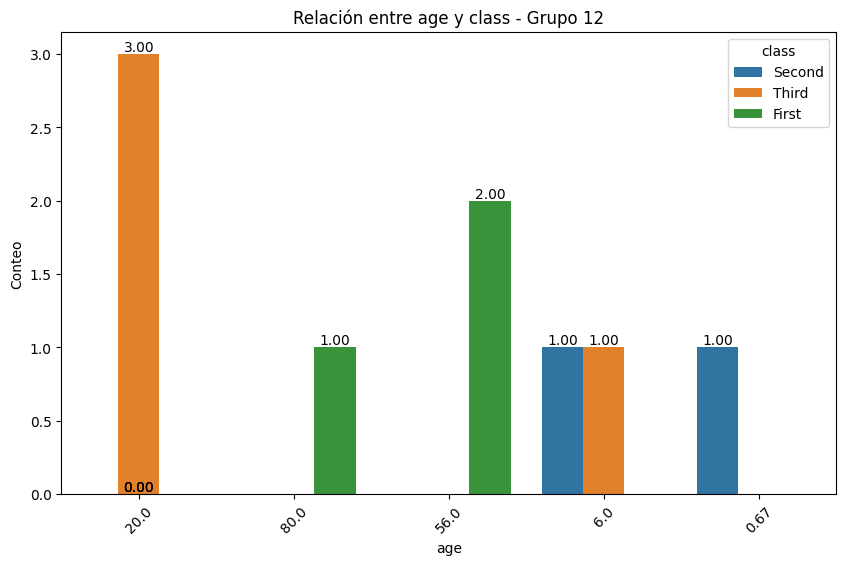

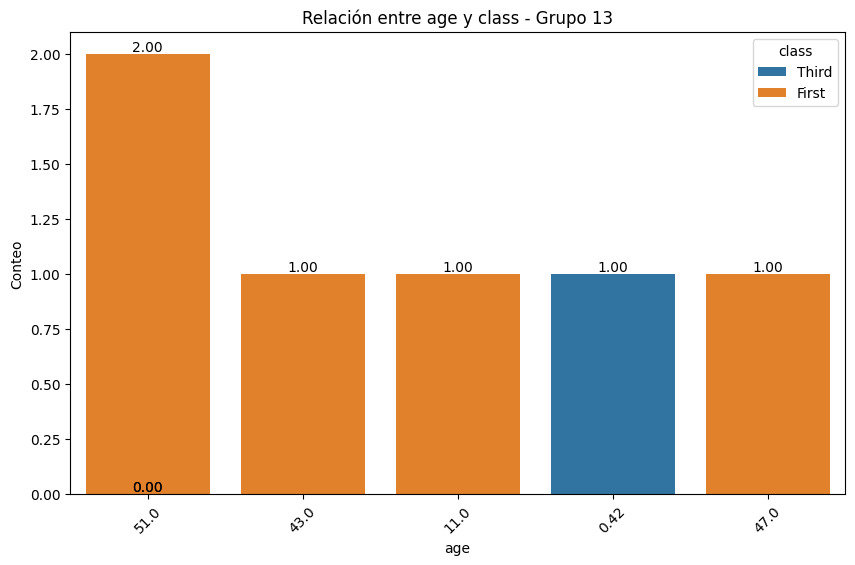

In [146]:
# Por si era justo eso lo que se preguntaba, aunque es menos interesante
# solo interesa el yes
for valor,df_datos in diccionario_multivariante.items():
    if valor == "yes":
        print(f"Respuesta {valor}:")
        plot_categorical_relationship_fin(df_datos,cof_2,cof_1, relative_freq= False, show_values= True)

El mayor número de supervivientes totales (absolutos) está en los 32 años. Hay un grupo de edad 32.5 que evidencia que este contraste bruto solo sirve a nivel informativo general.

In [152]:
# 8. age-fare-alive
corr_matrix_yes= df_titanic.loc[df_titanic.alive.isin(["yes"]), ["fare", "age"]].corr(numeric_only= True)
corr_matrix_no= df_titanic.loc[df_titanic.alive.isin(["no"]), ["fare", "age"]].corr(numeric_only= True)
print(f"SUPERVIVIENTES:\n{corr_matrix_yes}", f"FALLECIDOS:\n{corr_matrix_no}", sep ="\n"*2)

SUPERVIVIENTES:
          fare       age
fare  1.000000  0.146056
age   0.146056  1.000000

FALLECIDOS:
          fare       age
fare  1.000000  0.065276
age   0.065276  1.000000


La correlación ente la edad y el coste del billete respecto de su supervivencia en el incidente muestra una correlación muy baja.

In [156]:
# ANOVA alive-fare
from scipy import stats
grupos = df_titanic['alive'].unique()
supervivencia_por_ticket = [df_titanic[df_titanic['alive'] == grupo]['fare'] for grupo in grupos]
print([float(i) for i in stats.f_oneway(*supervivencia_por_ticket)])

[63.03076422804447, 6.120189341924269e-15]


El test ANOVA de la variable del precio del ticket según la supervivencia del pasajero da un p-valor menor que el nivel de significación establecido, por lo que tenemos suficiente evidencia estadística para afirmar que la media del precio del ticket difiere significativamente para los supevivientes que para los fallecidos.

In [157]:
# ANOVA 
from scipy import stats
grupos = df_titanic['alive'].unique()
supervivencia_por_edad = [df_titanic[df_titanic['alive'] == grupo]['age'] for grupo in grupos]
print([float(i) for i in stats.f_oneway(*supervivencia_por_edad)])

[5.182763957735943, 0.023048969172234354]


El test ANOVA de la variable edad según la supervivencia del pasajero da un p-valor menor que el nivel de significación establecido, por lo que tenemos suficiente evidencia estadística para afirmar que la media edad de los pasajeros difiere significativamente para los supevivientes que para los fallecidos.

Por lo tanto, las variables _fare_ y _age_ están relacionadas significativamente con la supervivencia de los pasajeros, pero no están correlacionadas entre sí separando los grupos por su supervivencia.

Si retirásemos los datos del personal del barco cuyo precio de ticket es nulo, podrían aparecer correlaciones entre el precio del ticket y la edad del pasajero según su supervivencia; dado que hemos visto anteriormente que los niños sobrevivieron en mayor proporción, pudiéndose evaluar una potencial relacion entre la supervivencia, el viaje en familia y el precio del ticket.

En adición, el contraste de estas tres variables entre sí puede beneficiarse de un contraste ANOVA de varios factores y un estudio de regresión múltiple.

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?